# 05 · Stress tests

| # | Test | Pass rule (fixed before running) |
|---|---|---|
| 1 | Bootstrap CI on the holdout | accuracy lower bound > 0.61 (always-Comedy) |
| 2 | Repeated 5×3 CV on all 600 shows | accuracy SD ≤ 0.05 |
| 3 | Gaussian noise 0.25 SD | accuracy drop ≤ 0.05 |
| 4 | +20% missing cells | accuracy drop ≤ 0.05 |
| 5 | 5% A unit errors injected | drop with the cleaning rule ≤ 0.01 (A is no longer a model input) |
| 6 | Adversarial validation (labelled vs unlabelled) | AUC ≤ 0.60 |
| 7 | 10% label noise (retrain) | accuracy drop ≤ 0.05 |
| 8 | Permutation test | real − max null macro-F1 ≥ 0.20 |
| 9 | Learning curve | reported |
| 10 | Label-quality audit (out-of-fold) | reported |
| 11 | Edge cases | probabilities finite and summing to 1 |

In [1]:
# --- Setup: make the project package importable from notebooks/ -------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

from src import config as cfg
print("Project root:", ROOT)

Project root: /home/claude/tv-genre-classification


In [2]:
# Rebuild the cleaned data if it is missing (fresh clone)
from src.data import make_dataset
if not cfg.TRAIN_FILE.exists():
    make_dataset.main()
# Train once if the saved models are missing (about 2 minutes)
if not all(cfg.model_file(m, "production").exists() for m in cfg.MODEL_NAMES):
    from src.features import build_features as bf
    from src.models import train_model as tm
    bf.run(); tm.run(); plt.close("all")
elif not cfg.SELECTED_FEATURES_FILE.exists():
    from src.features import build_features as bf
    bf.run(); plt.close("all")
from src.models import stress_test as st
names = ["bootstrap_ci", "repeated_cv", "corruption", "label_noise", "permutation", "learning_curve", "label_audit", "edge_cases"]
RUN_FULL = not all((cfg.TABLES_DIR / f"stress_{n}.csv").exists() for n in names)
if RUN_FULL:
    out = st.run(); plt.close("all")
R = {n: pd.read_csv(cfg.TABLES_DIR / f"stress_{n}.csv") for n in names}
R["summary"] = pd.read_csv(cfg.TABLES_DIR / "stress_test_summary.csv")
adv = pd.read_csv(cfg.TABLES_DIR / "stress_adversarial.csv").adversarial_auc.iloc[0]
print("computed" if RUN_FULL else "loaded saved", "results")

loaded saved results


Model,SSGMM,SVM-RBF,XGBoost
Test,,,
1 accuracy CI lower bound,PASS,PASS,PASS
11 edge cases,PASS,PASS,PASS
2 repeated CV accuracy (SD),PASS,PASS,PASS
3 noise 0.25 SD: accuracy drop,FAIL,FAIL,FAIL
4 +20% missing: accuracy drop,FAIL,FAIL,FAIL
5 A unit errors: drop raw / cleaned,PASS,PASS,PASS
6 adversarial validation AUC,PASS,PASS,PASS
7 10% label noise: accuracy drop,PASS,PASS,PASS
8 permutation: real vs null macro-F1,PASS,PASS,PASS


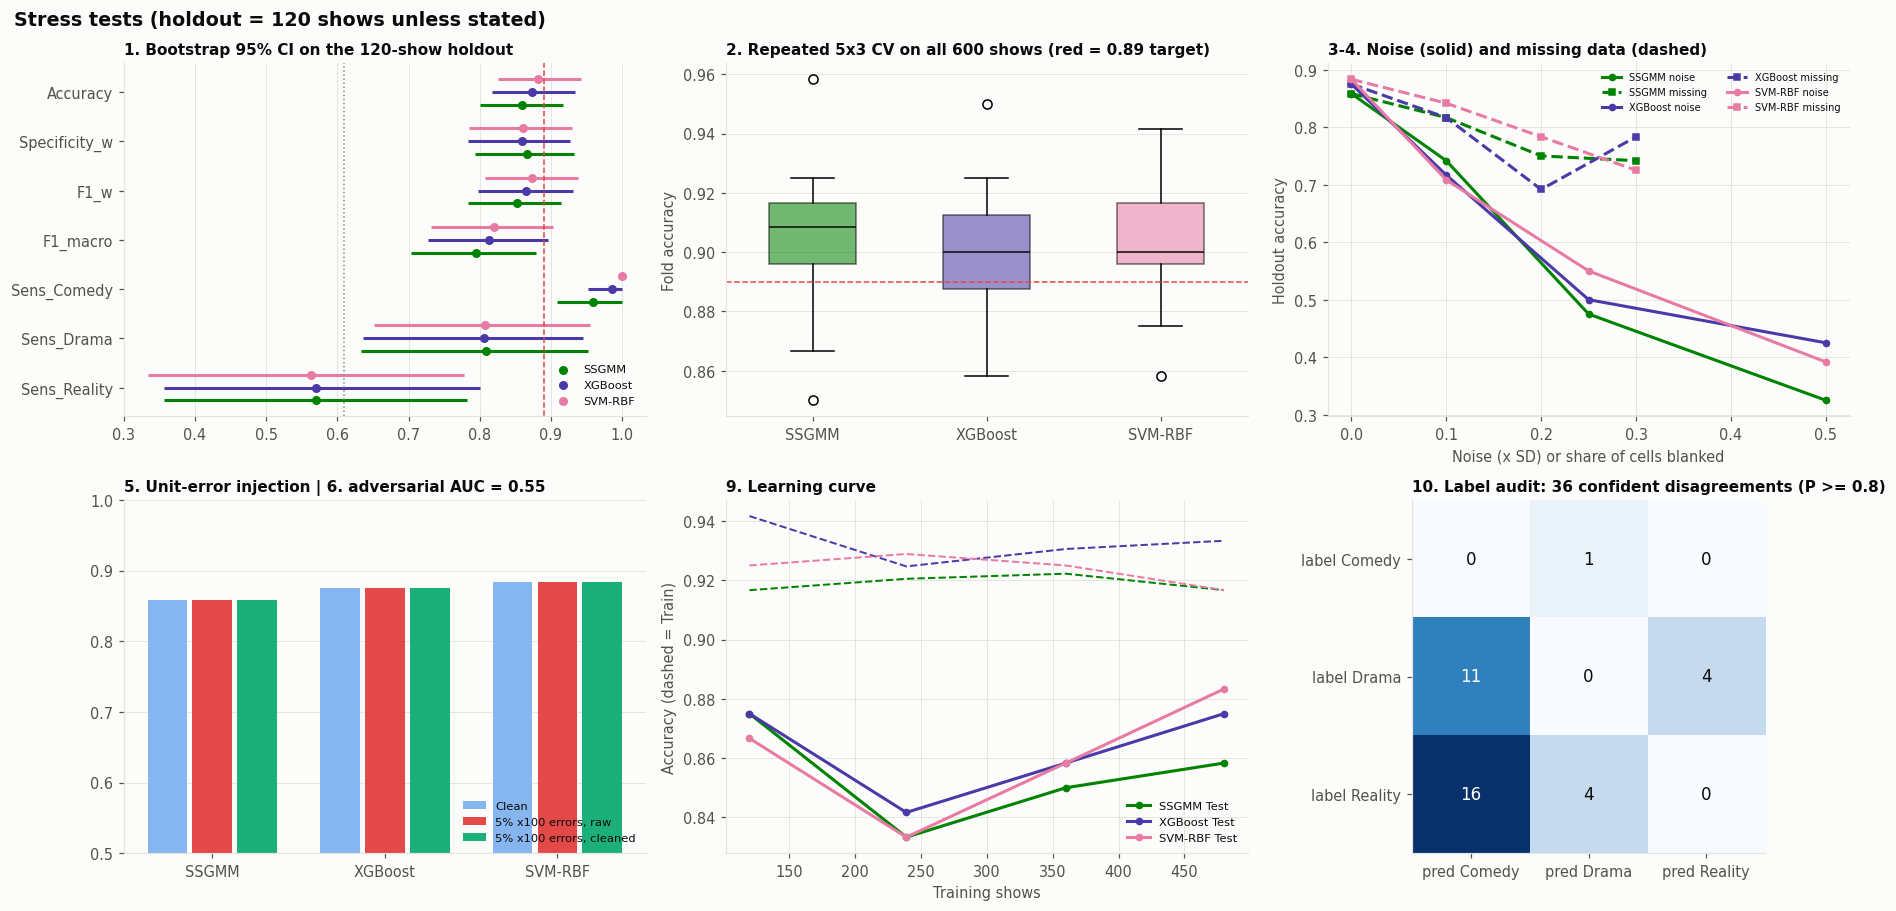

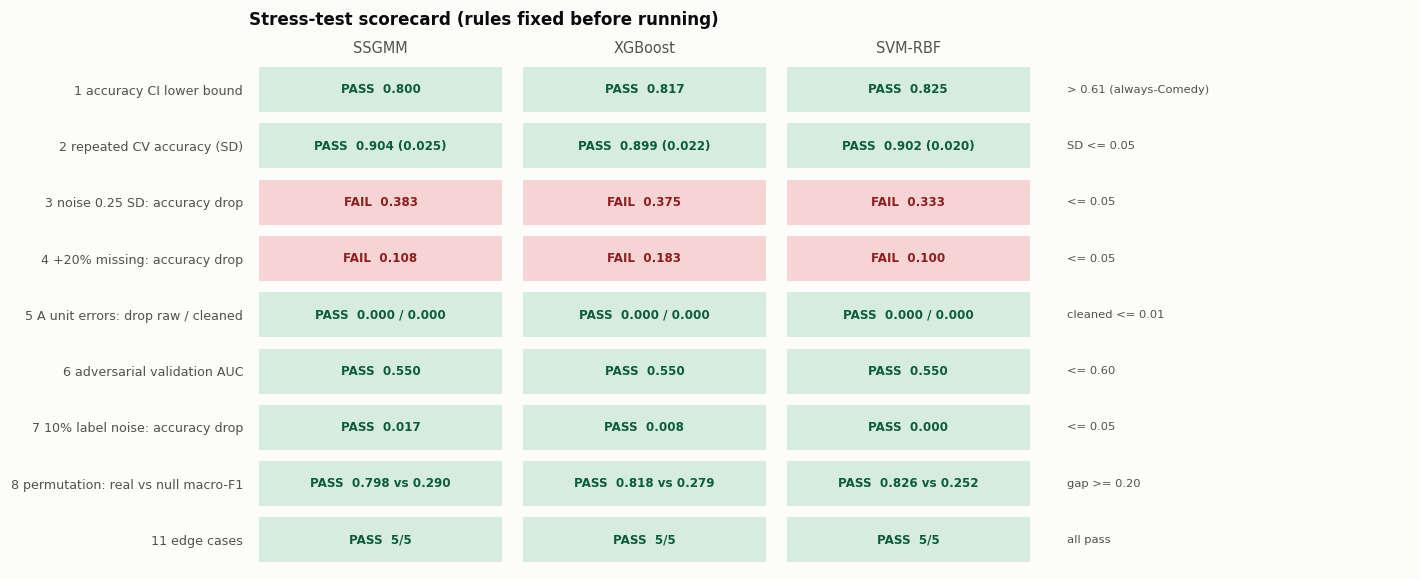

In [3]:
st.plot_all(R["bootstrap_ci"], R["repeated_cv"], R["corruption"], R["label_noise"], R["permutation"],
            R["learning_curve"], R["label_audit"], R["summary"], adv)
R["summary"].pivot(index="Test", columns="Model", values="Result")

In [4]:
R["summary"][R["summary"].Result == "FAIL"]

,Model,Test,Value,Rule,Result
2,SSGMM,3 noise 0.25 SD: accuracy drop,0.383,<= 0.05,FAIL
3,SSGMM,4 +20% missing: accuracy drop,0.108,<= 0.05,FAIL
11,XGBoost,3 noise 0.25 SD: accuracy drop,0.375,<= 0.05,FAIL
12,XGBoost,4 +20% missing: accuracy drop,0.183,<= 0.05,FAIL
20,SVM-RBF,3 noise 0.25 SD: accuracy drop,0.333,<= 0.05,FAIL
21,SVM-RBF,4 +20% missing: accuracy drop,0.100,<= 0.05,FAIL


## Noise and missing data

In [5]:
c = R["corruption"]
c[c.test.isin(["noise_sd", "missing"])].pivot_table(index=["test", "level"], columns="Model", values="Accuracy").round(3)

Model           SSGMM  SVM-RBF  XGBoost
test     level                         
missing  0.00   0.858    0.883    0.875
         0.10   0.817    0.842    0.817
         0.20   0.750    0.783    0.692
         0.30   0.742    0.725    0.783
noise_sd 0.00   0.858    0.883    0.875
         0.10   0.742    0.708    0.717
         0.25   0.475    0.550    0.500
         0.50   0.325    0.392    0.425

## Repeated cross-validation and bootstrap intervals

In [6]:
R["repeated_cv"].groupby("Model")[["Accuracy", "F1_macro", "AUC_macro"]].agg(["mean", "std"]).round(3)

Accuracy        F1_macro        AUC_macro       
            mean    std     mean    std      mean    std
Model                                                   
SSGMM      0.904  0.025    0.868  0.033     0.936  0.019
SVM-RBF    0.902  0.020    0.863  0.026     0.926  0.022
XGBoost    0.899  0.022    0.860  0.032     0.925  0.020

In [7]:
R["bootstrap_ci"].pivot(index="Metric", columns="Model", values=["mean", "ci_low", "ci_high"]).round(3)

mean                 ci_low                 ci_high                
Model          SSGMM SVM-RBF XGBoost  SSGMM SVM-RBF XGBoost   SSGMM SVM-RBF XGBoost
Metric                                                                             
AUC_macro      0.871   0.874   0.883  0.792   0.801   0.815   0.943   0.936   0.947
Accuracy       0.859   0.882   0.873  0.800   0.825   0.817   0.917   0.942   0.933
F1_macro       0.795   0.821   0.813  0.704   0.731   0.728   0.879   0.903   0.896
F1_w           0.852   0.873   0.865  0.783   0.807   0.798   0.913   0.938   0.931
Sens_Comedy    0.959   1.000   0.986  0.909   1.000   0.952   1.000   1.000   1.000
Sens_Drama     0.809   0.807   0.806  0.633   0.652   0.636   0.952   0.955   0.945
Sens_Reality   0.570   0.564   0.570  0.357   0.333   0.357   0.783   0.778   0.800
Specificity_w  0.867   0.860   0.859  0.793   0.784   0.783   0.932   0.929   0.927

## Learning curve and label audit

In [8]:
R["learning_curve"].round(3)

,Model,fraction,n,Train_acc,Test_acc,Test_F1
0,SSGMM,0.25,120,0.917,0.875,0.824
1,SSGMM,0.50,239,0.921,0.833,0.763
2,SSGMM,0.75,360,0.922,0.850,0.778
3,SSGMM,1.00,480,0.917,0.858,0.798
4,XGBoost,0.25,120,0.942,0.875,0.824
5,XGBoost,0.50,239,0.925,0.842,0.759
6,XGBoost,0.75,360,0.931,0.858,0.796
7,XGBoost,1.00,480,0.933,0.875,0.818
8,SVM-RBF,0.25,120,0.925,0.867,0.810
9,SVM-RBF,0.50,239,0.929,0.833,0.763


In [9]:
aud = R["label_audit"]
print(int(aud.suspect_label.sum()), "suspect labels")
aud[aud.suspect_label].head(15)

36 suspect labels


,show_id,genre,oof_P_Comedy,oof_P_Drama,oof_P_Reality,oof_pred,P_given_label,suspect_label
0,TR0150,Drama,0.967,0.011,0.022,Comedy,0.011,True
1,TR0408,Drama,0.868,0.011,0.120,Comedy,0.011,True
2,TR0250,Comedy,0.012,0.958,0.030,Drama,0.012,True
3,TR0009,Drama,0.963,0.012,0.025,Comedy,0.012,True
4,TR0371,Reality,0.014,0.975,0.012,Drama,0.012,True
5,TR0394,Drama,0.959,0.013,0.028,Comedy,0.013,True
6,TR0192,Drama,0.936,0.018,0.046,Comedy,0.018,True
7,TR0391,Drama,0.009,0.019,0.972,Reality,0.019,True
8,TR0443,Reality,0.971,0.009,0.020,Comedy,0.020,True
9,TR0433,Drama,0.952,0.023,0.024,Comedy,0.023,True


**Findings**

* Repeated CV accuracy is about 0.90 for all three models (fold SD ≈ 0.02), and the holdout bootstrap intervals include 0.89.
* **Precision dependence (weak point):** the accuracy comes from thin cluster shapes; Gaussian noise of 0.1 SD costs 0.12 to 0.17 accuracy, and 0.25 SD costs 0.33 to 0.38. Larger covariance ridges make the models more robust but cost the 0.89 target (tested 0.01 to 0.1: CV weakest metric falls from 0.89 to 0.81). Feeds must keep their current measurement precision; add precision checks upstream.
* **Missing data** is handled by marginalising the mixture over blank inputs (no imputation): +20% blank cells cost 0.10 to 0.18 accuracy (previously 0.32 with median imputation). Still above the 0.05 rule, so completeness checks remain necessary.
* Label noise (10% flipped) costs ≤ 0.02, there is no drift (adversarial AUC ≈ 0.55), and edge cases pass.
* The out-of-fold audit flags about 36 labels, mostly Drama or Reality shows that look like Comedy; re-checking them is the most direct way to raise the macro metrics.